# ResNet-50 (Frozen Backbone — Baseline)

## Goal

Establish a clean ResNet-50 baseline before any unfreezing or metadata fusion.

**Question being answered**: do ResNet-50's pretrained ImageNet features alone outperform ResNet-18 (augmented_v2, val F2 ~0.66)?

### Setup vs ResNet-18 augmented_v2

| | ResNet-18 augmented_v2 | ResNet-50 frozen baseline |
|---|---|---|
| Backbone | ResNet-18 (fully unfrozen) | ResNet-50 (frozen) |
| Augmentation | Strong (HFlip + VFlip + Rotation + ColorJitter + Affine) | Same |
| Optimizer | AdamW | AdamW |
| Weight decay | 1e-4 | 1e-4 |
| LR scheduler | CosineAnnealingLR | CosineAnnealingLR |
| Dropout | 0.4 | 0.5 (slightly stronger — larger model head risk) |
| DataLoader workers | 0 | 4 + persistent_workers |

### Rationale

Keeping the backbone fully frozen means only the 2048→1 FC head is trained (~2K parameters). This eliminates overfitting risk entirely and isolates whether ResNet-50's richer ImageNet features are directly useful for melanoma classification without any fine-tuning.

If frozen ResNet-50 already beats frozen/unfrozen ResNet-18, that validates the stronger backbone. The next iteration will selectively unfreeze the last residual block.

In [10]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.resnet import get_resnet50
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

In [11]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [12]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [13]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
    transform_train=get_augmented_train_transforms(image_size=224),
)

# persistent_workers keeps the worker processes alive between epochs,
# avoiding the per-epoch spawn overhead on Windows
train_loader.num_workers  # already set via get_dataloaders
train_loader = torch.utils.data.DataLoader(
    train_loader.dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

train_df = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


In [14]:
model     = get_resnet50(num_classes=1, freeze_backbone=True, dropout=0.5).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Higher LR is appropriate here — only the FC head is being trained,
# so there is no risk of destabilising pretrained weights
num_epochs = 40
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')

Trainable params: 2,049 / 23,510,081


In [15]:
best_val_f2 = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics   = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), ROOT / 'models/resnet50_frozen_baseline_best.pth')
        print(f'  -> Saved best model (val F2: {best_val_f2:.4f})')

Epoch [1/40] | Train Loss: 1.0673, Bal Acc: 0.6850, Recall: 0.6876, F2: 0.4733 | Val Loss: 0.9968, Bal Acc: 0.7269, Recall: 0.8263, F2: 0.5402
  -> Saved best model (val F2: 0.5402)


Epoch [2/40] | Train Loss: 0.9631, Bal Acc: 0.7345, Recall: 0.7777, F2: 0.5340 | Val Loss: 0.9453, Bal Acc: 0.7290, Recall: 0.8602, F2: 0.5439
  -> Saved best model (val F2: 0.5439)


Epoch [3/40] | Train Loss: 0.9389, Bal Acc: 0.7378, Recall: 0.7959, F2: 0.5382 | Val Loss: 0.9259, Bal Acc: 0.7442, Recall: 0.7881, F2: 0.5582
  -> Saved best model (val F2: 0.5582)


Epoch [4/40] | Train Loss: 0.9266, Bal Acc: 0.7340, Recall: 0.7799, F2: 0.5335 | Val Loss: 0.9224, Bal Acc: 0.7511, Recall: 0.7712, F2: 0.5663
  -> Saved best model (val F2: 0.5663)


Epoch [5/40] | Train Loss: 0.9346, Bal Acc: 0.7370, Recall: 0.7799, F2: 0.5371 | Val Loss: 0.9136, Bal Acc: 0.7510, Recall: 0.8136, F2: 0.5670
  -> Saved best model (val F2: 0.5670)


...

Epoch [36/40] | Train Loss: 0.8684, Bal Acc: 0.7541, Recall: 0.7902, F2: 0.5582 | Val Loss: 0.8492, Bal Acc: 0.7695, Recall: 0.8432, F2: 0.5898


Epoch [37/40] | Train Loss: 0.8783, Bal Acc: 0.7533, Recall: 0.7868, F2: 0.5573 | Val Loss: 0.8522, Bal Acc: 0.7710, Recall: 0.8305, F2: 0.5918
  -> Saved best model (val F2: 0.5918)


Epoch [38/40] | Train Loss: 0.8858, Bal Acc: 0.7619, Recall: 0.8039, F2: 0.5681 | Val Loss: 0.8513, Bal Acc: 0.7722, Recall: 0.8347, F2: 0.5934
  -> Saved best model (val F2: 0.5934)


Epoch [39/40] | Train Loss: 0.8709, Bal Acc: 0.7550, Recall: 0.7913, F2: 0.5594 | Val Loss: 0.8546, Bal Acc: 0.7626, Recall: 0.8008, F2: 0.5812


Epoch [40/40] | Train Loss: 0.8915, Bal Acc: 0.7571, Recall: 0.7948, F2: 0.5620 | Val Loss: 0.8483, Bal Acc: 0.7685, Recall: 0.8475, F2: 0.5886


## Training Curves

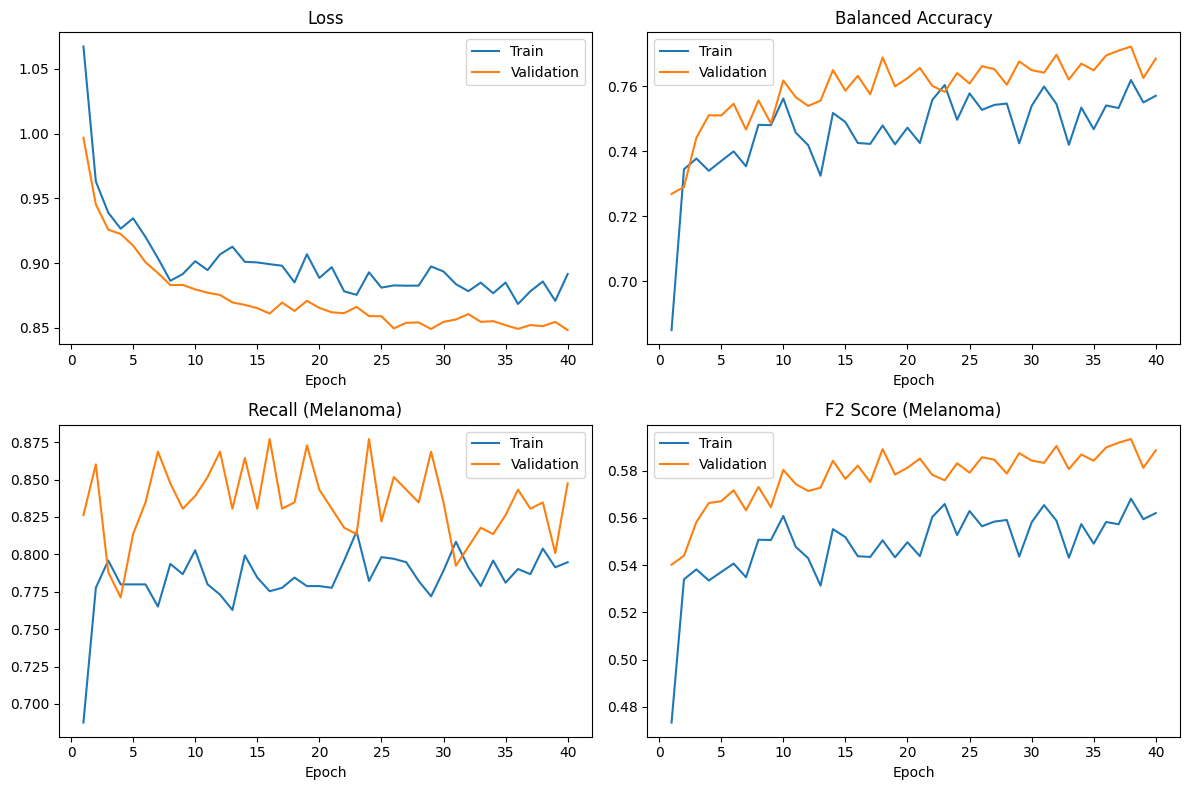

In [16]:
plot_training_curves(train_history, val_history)

## Threshold Tuning

In [17]:
model.load_state_dict(torch.load(str(ROOT / 'models/resnet50_frozen_baseline_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

Best threshold: 0.51 | Val F2: 0.5976


## Test Set Evaluation

Threshold:          0.51
AUC-ROC:            0.8369
Balanced Accuracy:  0.7517
F2 Score:           0.5615

              precision    recall  f1-score   support

Non-Melanoma     0.9651    0.7022    0.8130      1340
    Melanoma     0.2556    0.8012    0.3876       171

    accuracy                         0.7134      1511
   macro avg     0.6104    0.7517    0.6003      1511
weighted avg     0.8848    0.7134    0.7648      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


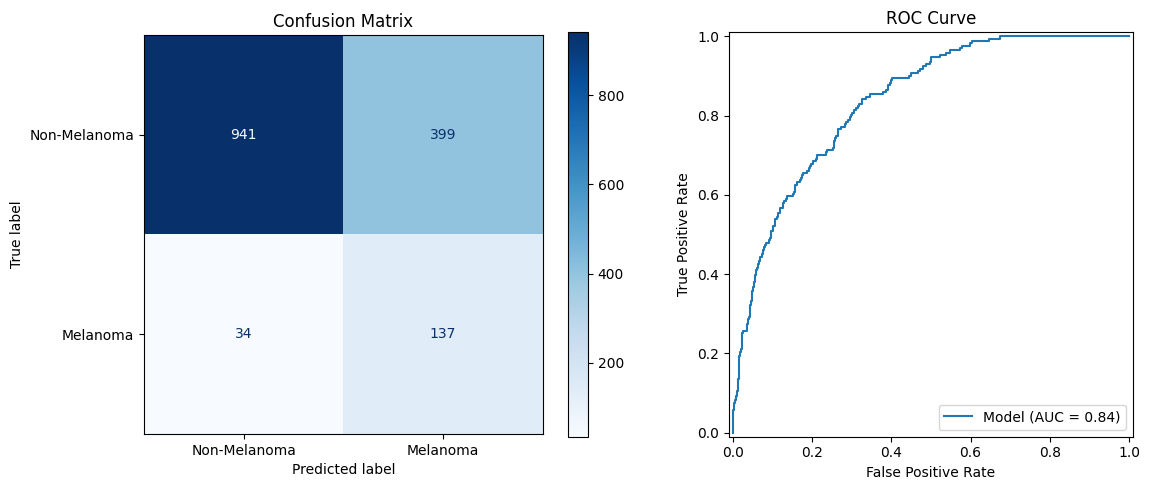

In [18]:
evaluate_model(model, test_loader, device, threshold=best_threshold)